# Heart Disease Prediction Using a Hybrid Feature Selection and Ensemble Learning Approach
## [Kelompok 5] Replikasi Paper (Gupta et al., IEEE Access 2025)

Notebook ini disusun ulang agar **setiap tahap mengikuti paper** sebisa mungkin:

| Tahap | Sumber di paper | Nilai yang dipakai |
|---|---|---|
| Split data | Sec. VII | 80:20, stratified, seed 42 |
| Preprocessing | Sec. III | IQR outlier removal (train saja) + Min-Max scaling |
| Hybrid GA+CSO (seleksi fitur) | Table 2, Algorithm 1 | pop 50, 100 generasi, mutasi 0,05, random walk 0,25, crossover 0,9, delta 5, Lévy λ 1,5 |
| GA standalone | Table 2 | pop 10, 20 generasi, crossover 0,9, mutasi 0,05 |
| CSA standalone | Sec. IV-A-2 | 50 nest, 100 iterasi, pa 0,25 |
| RF | Sec. IV-B-1, Table 3 | n_estimators 194, max_depth 43 |
| CNN | Sec. IV-B-2 | Conv1D 34 filter, kernel 2, MaxPool 2, Dense 50 ReLU, Sigmoid |
| Ensemble | Sec. IV-B | Majority voting RF + CNN |
| Tuning | Sec. IV-B-C | Hyperparameter final dari GA (Table 3) |

**Catatan:** Ada beberapa bagian paper yang ambigu. Keputusan yang diambil untuk setiap ambiguitas ditandai dengan komentar `# ASUMSI` di kode.


## 1. Setup dan Seed

In [1]:
import os, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

I0000 00:00:1790316545.726406   66037 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790316545.726779   66037 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790316545.760498   66037 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790316546.640784   66037 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## 2. Load Data dan Split (sebelum preprocessing, untuk mencegah data leakage)

In [2]:
PATH = './dataset/heart_disease_cleveland.csv'
df = pd.read_csv(PATH).rename(columns={'target': 'num'})
TARGET = 'num'

feature_cols = [c for c in df.columns if c != TARGET]
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = [c for c in feature_cols if c not in continuous_cols]

train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED,
                                     stratify=df[TARGET])
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print('Train:', train_df.shape, '| Test:', test_df.shape)
print('Distribusi kelas train:', train_df[TARGET].value_counts().to_dict())

Train: (242, 14) | Test: (61, 14)
Distribusi kelas train: {0: 131, 1: 111}


## 3. Preprocessing (Improved): Imputasi, Log1p, IQR Clipping, One-Hot Encoding, Min-Max (fit hanya pada train)

In [3]:
# ==== Preprocessing (IMPROVED — lihat preprocessing_improvement.ipynb) ====
# Ablation pada preprocessing_improvement.ipynb menunjukkan konfigurasi terbaik (RF) adalah
# one-hot encoding (nominal) + log1p (kolom skew) + IQR clipping/winsorize (bukan menghapus baris).
# Semua operasi yang belajar dari data (imputasi, log, batas IQR, one-hot, scaling) tetap
# di-fit HANYA pada train, lalu diterapkan ke test -> tidak ada data leakage.
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder

NOMINAL_COLS = ['cp', 'restecg', 'slope', 'thal', 'ca']  # ASUMSI: nominal (bukan ordinal) -> one-hot
BINARY_COLS  = ['sex', 'fbs', 'exang']                   # biner: tetap Min-Max (0/1, tidak ada ordering palsu)
LOG_COLS     = ['chol', 'oldpeak']                       # skew > 1 (lihat preprocessing_improvement.ipynb bagian 2.1)

class IQRClipper(BaseEstimator, TransformerMixin):
    """Winsorize dengan batas IQR (baris TIDAK dihapus). Batas dihitung dari data fit (train saja)."""
    def __init__(self, k=1.5):
        self.k = k
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1, q3 = np.nanpercentile(X, 25, axis=0), np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.lo_, self.hi_ = q1 - self.k * iqr, q3 + self.k * iqr
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lo_, self.hi_)

# Imputasi (median untuk kontinu, modus untuk kategorikal) -- sama seperti sebelumnya
num_imp = SimpleImputer(strategy='median')
cat_imp = SimpleImputer(strategy='most_frequent')
train_df[continuous_cols] = num_imp.fit_transform(train_df[continuous_cols])
test_df[continuous_cols]  = num_imp.transform(test_df[continuous_cols])
train_df[categorical_cols] = cat_imp.fit_transform(train_df[categorical_cols])
test_df[categorical_cols]  = cat_imp.transform(test_df[categorical_cols])
n_rows = len(train_df)

# Log1p pada kolom skew (transformasi monoton, dilakukan sebelum clipping & scaling)
for c in LOG_COLS:
    train_df[c] = np.log1p(train_df[c])
    test_df[c]  = np.log1p(test_df[c])

# IQR clipping (winsorize): batas dari TRAIN saja, baris TIDAK dibuang (beda dari versi sebelumnya
# yang menghapus baris outlier dari train -> ukuran sampel train kini tetap penuh)
clipper = IQRClipper()
train_df[continuous_cols] = clipper.fit_transform(train_df[continuous_cols])
test_df[continuous_cols]  = clipper.transform(test_df[continuous_cols])
print(f'Baris train dipertahankan: {n_rows} (outlier di-clip/winsorize, bukan dihapus)')

# One-hot encoding untuk kolom nominal (menghilangkan ordering palsu antar-kategori)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
nom_names = list(ohe.fit(train_df[NOMINAL_COLS]).get_feature_names_out(NOMINAL_COLS))
train_nom = pd.DataFrame(ohe.transform(train_df[NOMINAL_COLS]), columns=nom_names, index=train_df.index)
test_nom  = pd.DataFrame(ohe.transform(test_df[NOMINAL_COLS]),  columns=nom_names, index=test_df.index)

# Min-Max scaling (fit di train) untuk kolom kontinu + biner; kolom nominal sudah 0/1 dari one-hot
scale_cols = continuous_cols + BINARY_COLS
scaler = MinMaxScaler()
train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
test_df[scale_cols]  = scaler.transform(test_df[scale_cols])

train_df = pd.concat([train_df.drop(columns=NOMINAL_COLS), train_nom], axis=1)
test_df  = pd.concat([test_df.drop(columns=NOMINAL_COLS),  test_nom],  axis=1)

feature_cols = continuous_cols + BINARY_COLS + nom_names  # diperbarui: nominal sekarang one-hot

X_train = train_df[feature_cols].to_numpy(dtype=float)
y_train = train_df[TARGET].to_numpy(dtype=int)
X_test  = test_df[feature_cols].to_numpy(dtype=float)
y_test  = test_df[TARGET].to_numpy(dtype=int)
n_features = X_train.shape[1]

assert not np.isnan(X_train).any() and not np.isnan(X_test).any()
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('feature_cols (setelah one-hot):', feature_cols)

Baris train dipertahankan: 242 (outlier di-clip/winsorize, bukan dihapus)
X_train: (242, 25) | X_test: (61, 25)
feature_cols (setelah one-hot): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'fbs', 'exang', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0']


## 4. Fitness Function untuk Seleksi Fitur (wrapper)
Fitness memakai RF ringan dengan 3-fold StratifiedKFold pada **train saja**.

In [4]:
RNG_SEED = SEED
_fitness_cache = {}
_clf_template = dict(n_estimators=10, max_depth=5, n_jobs=1, random_state=RNG_SEED)
_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG_SEED)

def sigmoid(v):
    return 1 / (1 + np.exp(-v))

def to_binary_mask(vec):
    probs = sigmoid(vec)
    mask = probs > 0.5
    if not mask.any():                 # subset kosong tidak diizinkan
        mask[np.argmax(probs)] = True
    return mask

def objective_value(vec):
    """Lower is better (Fig. 3 paper)."""
    mask = to_binary_mask(vec)
    key = mask.tobytes()
    if key in _fitness_cache:
        return _fitness_cache[key]
    acc = cross_val_score(RandomForestClassifier(**_clf_template),
                          X_train[:, mask], y_train, cv=_cv, scoring='accuracy').mean()
    frac = mask.sum() / len(mask)
    obj = 100.0 * ((1 - acc) + 0.01 * frac)
    _fitness_cache[key] = obj
    return obj

## 5. Algoritma Seleksi Fitur: GA, CSA, dan Hybrid GA+CSO

In [5]:
def levy_flight(shape, rng, beta=1.5):
    num = math.gamma(1 + beta) * np.sin(np.pi * beta / 2)
    den = math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2)
    sigma_u = (num / den) ** (1 / beta)
    u = rng.normal(0, sigma_u, size=shape)
    v = rng.normal(0, 1, size=shape)
    return u / (np.abs(v) ** (1 / beta))

# --- GA standalone (Table 2: pop 10, gen 20, crossover 0.9, mutasi 0.05) ---
def genetic_algorithm(n_dims, objective_fn, pop_size=10, generations=20,
                      crossover_prob=0.9, mutation_prob=0.05, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    pop = rng.uniform(-1, 1, size=(pop_size, n_dims))
    obj = np.array([objective_fn(ind) for ind in pop])
    best_idx = obj.argmin()
    best_vec, best_obj = pop[best_idx].copy(), obj[best_idx]
    history = [best_obj]
    for _ in range(generations):
        fit = -obj
        fit = fit - fit.min() + 1e-6
        probs = fit / fit.sum()
        parents = pop[rng.choice(pop_size, size=pop_size, p=probs)]
        children = parents.copy()
        for i in range(0, pop_size - 1, 2):
            if rng.random() < crossover_prob:
                pt = rng.integers(1, n_dims)
                children[i, pt:], children[i+1, pt:] = parents[i+1, pt:].copy(), parents[i, pt:].copy()
        mut = rng.random(children.shape) < mutation_prob
        children[mut] += rng.normal(0, 0.5, size=mut.sum())
        children[0] = best_vec                         # elitism
        pop = children
        obj = np.array([objective_fn(ind) for ind in pop])
        if obj.min() < best_obj:
            best_obj, best_vec = obj.min(), pop[obj.argmin()].copy()
        history.append(best_obj)
    return best_vec, best_obj, history

# --- CSA standalone (50 nest, 100 iterasi, pa 0.25) ---
def cuckoo_search(n_dims, objective_fn, n_nests=50, iterations=100, pa=0.25,
                  levy_lambda=1.5, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    nests = rng.uniform(-1, 1, size=(n_nests, n_dims))
    obj = np.array([objective_fn(n) for n in nests])
    best_idx = obj.argmin()
    best_vec, best_obj = nests[best_idx].copy(), obj[best_idx]
    history = [best_obj]
    for _ in range(iterations):
        step = levy_flight(nests.shape, rng, beta=levy_lambda)
        new_nests = nests + 0.01 * step * (nests - best_vec)
        new_obj = np.array([objective_fn(n) for n in new_nests])
        improved = new_obj < obj
        nests[improved], obj[improved] = new_nests[improved], new_obj[improved]
        n_abandon = int(pa * n_nests)
        worst = np.argsort(obj)[-n_abandon:]
        nests[worst] = rng.uniform(-1, 1, size=(n_abandon, n_dims))
        obj[worst] = [objective_fn(n) for n in nests[worst]]
        if obj.min() < best_obj:
            best_obj, best_vec = obj.min(), nests[obj.argmin()].copy()
        history.append(best_obj)
    return best_vec, best_obj, history

# --- Hybrid GA+CSO (Algorithm 1: pop 50, gen 100, delta 5, random walk 0.25) ---
def hybrid_ga_cso(n_dims, objective_fn, pop_size=50, generations=100,
                  mutation_prob=0.05, random_walk_prob=0.25, delta=5,
                  levy_lambda=1.5, alpha=0.01, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    pop = rng.uniform(-1, 1, size=(pop_size, n_dims))
    obj = np.array([objective_fn(ind) for ind in pop])
    gbest_vec, gbest_obj = pop[obj.argmin()].copy(), obj.min()
    history = [gbest_obj]
    stagnant = 0
    for _ in range(generations):
        # (4-6) Lévy flight update menuju gbest
        step = levy_flight(pop.shape, rng, beta=levy_lambda)
        pop = pop + alpha * step * (pop - gbest_vec)
        obj = np.array([objective_fn(ind) for ind in pop])
        if obj.min() < gbest_obj:
            gbest_obj, gbest_vec = obj.min(), pop[obj.argmin()].copy()
        # (7-11) random walk untuk sebagian individu, lalu repair
        do_walk = rng.random(pop_size) < random_walk_prob
        for i in np.where(do_walk)[0]:
            xk, xj = pop[rng.choice(pop_size, 2, replace=False)]
            pop[i] = pop[i] + rng.random() * (xk - xj)
        pop = np.clip(pop, -3, 3)
        obj = np.array([objective_fn(ind) for ind in pop])
        if obj.min() < gbest_obj:
            gbest_obj, gbest_vec = obj.min(), pop[obj.argmin()].copy()
            stagnant = 0
        else:
            stagnant += 1
        # (13-14) swap mutation jika gbest stagnan selama delta generasi
        if stagnant >= delta:
            idx = rng.integers(0, pop_size)
            i, j = rng.choice(n_dims, 2, replace=False)
            pop[idx, [i, j]] = pop[idx, [j, i]]
            if rng.random() < mutation_prob:
                pop[idx] += rng.normal(0, 0.5, size=n_dims)
            stagnant = 0
        obj = np.array([objective_fn(ind) for ind in pop])
        if obj.min() < gbest_obj:
            gbest_obj, gbest_vec = obj.min(), pop[obj.argmin()].copy()
        history.append(gbest_obj)
    return gbest_vec, gbest_obj, history

# Jalankan ketiganya dengan budget paper
ga_vec, ga_obj, ga_hist   = genetic_algorithm(n_features, objective_value)
csa_vec, csa_obj, csa_hist = cuckoo_search(n_features, objective_value)
hyb_vec, hyb_obj, hyb_hist = hybrid_ga_cso(n_features, objective_value)

print(f'GA          best obj: {ga_obj:.3f} | fitur: {[f for f,m in zip(feature_cols, to_binary_mask(ga_vec)) if m]}')
print(f'CSA         best obj: {csa_obj:.3f} | fitur: {[f for f,m in zip(feature_cols, to_binary_mask(csa_vec)) if m]}')
print(f'Hybrid GA+CSO best obj: {hyb_obj:.3f} | fitur: {[f for f,m in zip(feature_cols, to_binary_mask(hyb_vec)) if m]}')

GA          best obj: 15.578 | fitur: ['exang', 'cp_4.0', 'restecg_2.0', 'slope_1.0', 'thal_3.0', 'ca_0.0', 'ca_1.0']
CSA         best obj: 15.422 | fitur: ['age', 'chol', 'sex', 'fbs', 'cp_1.0', 'cp_2.0', 'cp_4.0', 'restecg_0.0', 'slope_1.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'ca_1.0']
Hybrid GA+CSO best obj: 14.092 | fitur: ['thalach', 'fbs', 'cp_1.0', 'cp_4.0', 'restecg_0.0', 'restecg_2.0', 'slope_1.0', 'thal_6.0', 'thal_7.0', 'ca_0.0', 'ca_1.0']


### 5.1 Konvergensi (mereproduksi Fig. 3)

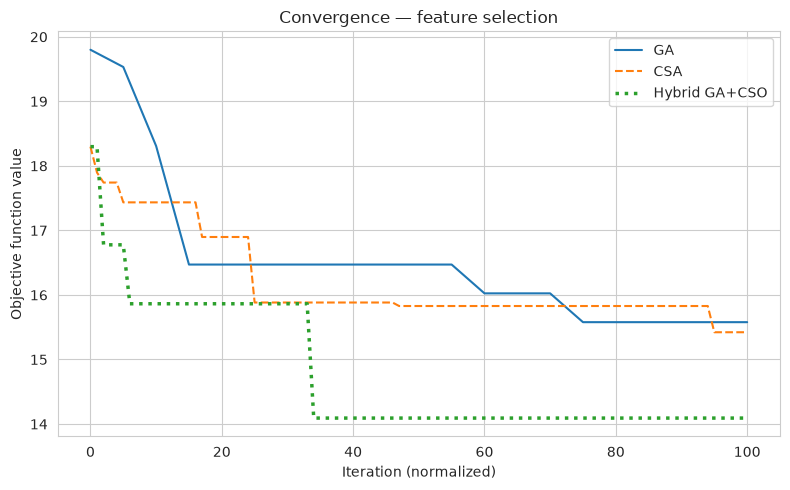

In [6]:
def align_length(hist, target_len):
    x_old = np.linspace(0, 1, len(hist))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, hist)

max_len = max(len(ga_hist), len(csa_hist), len(hyb_hist))
plt.figure(figsize=(8, 5))
plt.plot(align_length(ga_hist, max_len), label='GA', linestyle='-')
plt.plot(align_length(csa_hist, max_len), label='CSA', linestyle='--')
plt.plot(align_length(hyb_hist, max_len), label='Hybrid GA+CSO', linestyle=':', linewidth=2.5)
plt.xlabel('Iteration (normalized)')
plt.ylabel('Objective function value')
plt.title('Convergence — feature selection')
plt.legend(); plt.tight_layout(); plt.show()

### 5.2 Stabilitas antar-seed (paper tidak melaporkan ini; ditambahkan untuk verifikasi)

In [7]:
def run_trial(seed):
    _, g, _ = genetic_algorithm(n_features, objective_value, seed=seed)
    _, c, _ = cuckoo_search(n_features, objective_value, seed=seed)
    _, h, _ = hybrid_ga_cso(n_features, objective_value, seed=seed)
    return g, c, h

trials = pd.DataFrame([run_trial(s) for s in range(5)],
                      columns=['GA', 'CSA', 'Hybrid GA+CSO'])
trials.index.name = 'seed'
trials.loc['mean'] = trials.mean()
trials.loc['std'] = trials.iloc[:5].std()
trials

,GA,CSA,Hybrid GA+CSO
seed,,,
0,15.818354,14.057407,16.526543
1,15.773210,15.728066,15.693210
2,17.103210,14.985021,16.235021
3,15.818354,15.331975,15.753786
4,16.636255,15.778354,16.174444
mean,16.229877,15.176165,16.076601
std,0.607269,0.703502,0.349398


## 6. Seleksi Fitur Final: Hybrid GA+CSO

In [8]:
hybrid_mask = to_binary_mask(hyb_vec)
selected_features = [f for f, m in zip(feature_cols, hybrid_mask) if m]
X_train_sel = X_train[:, hybrid_mask]
X_test_sel  = X_test[:, hybrid_mask]
print('Fitur terpilih:', selected_features)
print('X_train_sel:', X_train_sel.shape, '| X_test_sel:', X_test_sel.shape)

Fitur terpilih: ['thalach', 'fbs', 'cp_1.0', 'cp_4.0', 'restecg_0.0', 'restecg_2.0', 'slope_1.0', 'thal_6.0', 'thal_7.0', 'ca_0.0', 'ca_1.0']
X_train_sel: (242, 11) | X_test_sel: (61, 11)


## 7. Hyperparameter (sesuai Table 3 paper)
Paper melaporkan hasil tuning GA. Nilai final yang dipakai adalah nilai yang dilaporkan paper.
Blok GA-tuning di bawah bisa dijalankan dengan `RUN_GA_TUNING = True` untuk verifikasi.

In [9]:
RUN_GA_TUNING = False

# ASUMSI: Table 3 menulis 190 estimator, teks Sec. IV-B-1 menulis 194. Dipakai 194 (teks).
RF_PARAMS  = dict(n_estimators=194, max_depth=43, random_state=SEED)
CNN_PARAMS = dict(filters=34, kernel_size=2, dense_units=50,
                  learning_rate=1e-3, epochs=50, batch_size=32)  # ASUMSI: epoch & batch tidak dilaporkan paper

ENS_HP_BOUNDS = {
    'rf_n_estimators': (10, 300), 'rf_max_depth': (2, 50),
    'cnn_filters': (8, 64), 'cnn_kernel_size': (2, 4), 'cnn_dense_units': (16, 128),
}
ENS_HP_NAMES = list(ENS_HP_BOUNDS)
ENS_HP_INT = {'rf_n_estimators', 'rf_max_depth', 'cnn_filters', 'cnn_kernel_size', 'cnn_dense_units'}

def decode_hp(vec):
    s = (np.clip(vec, -1, 1) + 1) / 2
    raw = {}
    for name, v in zip(ENS_HP_NAMES, s):
        lo, hi = ENS_HP_BOUNDS[name]
        val = lo + v * (hi - lo)
        raw[name] = int(round(val)) if name in ENS_HP_INT else float(val)
    rf = dict(n_estimators=raw['rf_n_estimators'], max_depth=raw['rf_max_depth'], random_state=SEED)
    cnn = dict(filters=raw['cnn_filters'], kernel_size=raw['cnn_kernel_size'],
               dense_units=raw['cnn_dense_units'], learning_rate=1e-3, epochs=50, batch_size=32)
    return rf, cnn

def build_cnn(n_in, filters, kernel_size, dense_units, learning_rate):
    m = Sequential([
        Conv1D(filters, kernel_size, activation='relu', input_shape=(n_in, 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dense(1, activation='sigmoid'),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m

if RUN_GA_TUNING:
    # Objektif: 100 * (1 - akurasi) pada validation split dari train (tidak menyentuh test)
    Xtr, Xval, ytr, yval = train_test_split(X_train_sel, y_train, test_size=0.2,
                                            random_state=SEED, stratify=y_train)
    def objective_hp(vec):
        rf_p, cnn_p = decode_hp(vec)
        rf_ = RandomForestClassifier(**rf_p, n_jobs=1).fit(Xtr, ytr)
        cnn_ = build_cnn(Xtr.shape[1], cnn_p['filters'], cnn_p['kernel_size'],
                         cnn_p['dense_units'], cnn_p['learning_rate'])
        cnn_.fit(Xtr.reshape(-1, Xtr.shape[1], 1), ytr, epochs=cnn_p['epochs'],
                 batch_size=cnn_p['batch_size'], verbose=0)
        p = 0.5 * rf_.predict_proba(Xval)[:, 1] + 0.5 * cnn_.predict(
            Xval.reshape(-1, Xval.shape[1], 1), verbose=0).ravel()
        return 100.0 * (1 - accuracy_score(yval, (p >= 0.5).astype(int)))

    hp_vec, hp_obj, _ = genetic_algorithm(len(ENS_HP_NAMES), objective_hp, pop_size=10, generations=20)
    rf_tuned, cnn_tuned = decode_hp(hp_vec)
    RF_PARAMS = rf_tuned
    CNN_PARAMS = {**CNN_PARAMS, **{k: v for k, v in cnn_tuned.items() if k != 'random_state'}}
    print('Hyperparameter hasil GA:', RF_PARAMS, CNN_PARAMS)

print('RF :', RF_PARAMS)
print('CNN:', CNN_PARAMS)

RF : {'n_estimators': 194, 'max_depth': 43, 'random_state': 42}
CNN: {'filters': 34, 'kernel_size': 2, 'dense_units': 50, 'learning_rate': 0.001, 'epochs': 50, 'batch_size': 32}


## 8. Model: Random Forest dan CNN pada fitur terpilih

In [10]:
rf = RandomForestClassifier(**RF_PARAMS)
rf.fit(X_train_sel, y_train)
rf_prob = rf.predict_proba(X_test_sel)[:, 1]

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
cnn = build_cnn(X_train_sel.shape[1], CNN_PARAMS['filters'], CNN_PARAMS['kernel_size'],
                CNN_PARAMS['dense_units'], CNN_PARAMS['learning_rate'])
cnn.fit(X_train_sel.reshape(-1, X_train_sel.shape[1], 1), y_train,
        epochs=CNN_PARAMS['epochs'], batch_size=CNN_PARAMS['batch_size'],
        validation_split=0.2, verbose=0)
cnn_prob = cnn.predict(X_test_sel.reshape(-1, X_test_sel.shape[1], 1), verbose=0).ravel()

/home/messciente/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790317027.293683   66037 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1790317027.293967   71767 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1790317027.318295   66037 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would li

## 9. Ensemble Majority Voting (RF + CNN)
Paper menyatakan majority voting. Dengan dua model, voting bisa seri saat keduanya tidak sepakat.
**ASUMSI:** jika seri, keputusan diambil dari rata-rata probabilitas kedua model.

In [11]:
def majority_vote(p_rf, p_cnn, thr=0.5):
    y_rf  = (p_rf  >= thr).astype(int)
    y_cnn = (p_cnn >= thr).astype(int)
    votes = y_rf + y_cnn
    avg = 0.5 * p_rf + 0.5 * p_cnn
    pred = np.where(votes == 2, 1, np.where(votes == 0, 0, (avg >= thr).astype(int)))
    return pred, avg

ens_pred, ens_prob = majority_vote(rf_prob, cnn_prob)

## 10. Evaluasi pada Test Set

In [12]:
def evaluate(name, y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {'model': name,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred),
            'recall': recall_score(y_true, y_pred),
            'f1': f1_score(y_true, y_pred),
            'specificity': tn / (tn + fp),
            'roc_auc': roc_auc_score(y_true, y_prob)}

results = pd.DataFrame([
    evaluate('Random Forest', y_test, (rf_prob >= 0.5).astype(int), rf_prob),
    evaluate('CNN', y_test, (cnn_prob >= 0.5).astype(int), cnn_prob),
    evaluate('Proposed (RF+CNN majority voting)', y_test, ens_pred, ens_prob),
]).set_index('model')
results.round(4)

,accuracy,precision,recall,f1,specificity,roc_auc
model,,,,,,
Random Forest,0.8361,0.8000,0.8571,0.8276,0.8182,0.9199
CNN,0.8361,0.8000,0.8571,0.8276,0.8182,0.8950
Proposed (RF+CNN majority voting),0.8525,0.8276,0.8571,0.8421,0.8485,0.9199


### 10.1 Confusion matrix

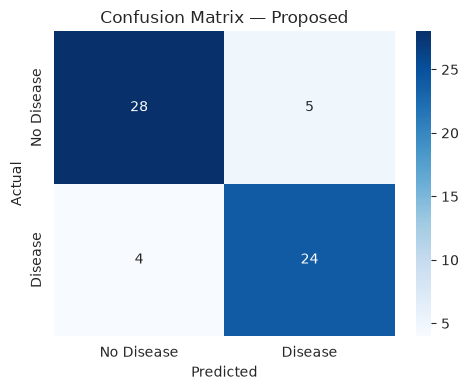

In [13]:
cm = confusion_matrix(y_test, ens_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix — Proposed')
plt.tight_layout(); plt.show()

## 11. Perbandingan dengan Angka Paper (Table 5 dan Table 7)

In [14]:
paper_reported = pd.DataFrame([
    {'model': 'Paper: Proposed', 'accuracy': 0.95, 'precision': 0.9565,
     'recall': 0.917, 'f1': 0.9361, 'specificity': 0.9722, 'roc_auc': 0.9502},
]).set_index('model')

comparison = pd.concat([paper_reported, results.loc[['Proposed (RF+CNN majority voting)']]
                        .rename(index={'Proposed (RF+CNN majority voting)': 'Replikasi: Proposed'})])
comparison.round(4)

,accuracy,precision,recall,f1,specificity,roc_auc
model,,,,,,
Paper: Proposed,0.9500,0.9565,0.9170,0.9361,0.9722,0.9502
Replikasi: Proposed,0.8525,0.8276,0.8571,0.8421,0.8485,0.9199


## 12. Simpan Hasil
Hasil disimpan agar dapat dipakai untuk laporan dan reproduksi.

In [15]:
os.makedirs('./outputs', exist_ok=True)
results.to_csv('./outputs/results_test_set.csv')
trials.to_csv('./outputs/feature_selection_seed_trials.csv')
print('Tersimpan di ./outputs/')

Tersimpan di ./outputs/
